# Prompt-only vs Teacher-forced ARC Comparison

`analyze_arc_mistake_iterations.ipynb` を軽量化した比較用 notebook です。同じ ARC sample に対して、teacher-forced next-token 評価と prompt-only autoregressive 生成を並べて確認します。

In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import BoundaryNorm, ListedColormap

from autoregressive_eval_URM import _generate_urm_batch, _resolve_casual_token_ids
from evaluate_trained_model import (
    apply_eval_overrides,
    load_config_from_checkpoint,
    _checkpoint_step,
    _resolve_checkpoint_path,
)
from models.losses import IGNORE_LABEL_ID
from pretrain import create_dataloader, init_train_state, _get_loop_config, _load_model_state
from puzzle_dataset import PuzzleDatasetConfig
from puzzle_full_dataset import PuzzleFullDataset

plt.rcParams["figure.dpi"] = 120

In [2]:
# ここを変更してください
CHECKPOINT = "checkpoints/URM-arcagi1-full-gen-l4-casual/step_23828.pt"
DATASET_DIR = None  # None なら checkpoint の config.data_path を使う

SPLIT = "train"  # "train" or "test"
GROUP_ID = 0
PUZZLE_ID = 0
PUZZLE_ID_MODE = "local"  # "local", "absolute", or "auto"
EXAMPLE_ID = 0
EXAMPLE_ID_MODE = "local"  # "local", "absolute", "auto", or "random"
RANDOM_SEED = 0

TRAIN_CONTEXT_COUNT = 3
LOOPS_TO_RUN = 16
PROMPT_ONLY_EXTRA_TOKENS = 20

# train split の複数サンプルをまとめて比較します。重い場合は False にしてください。
RUN_TRAIN_SCAN = True
TRAIN_SCAN_SAMPLE_COUNT = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


In [3]:
ARC_TOKEN_PAD = 0
ARC_TOKEN_EOS = 1
ARC_TOKEN_COLOR_OFFSET = 2
ARC_NUM_TOKENS = 12

ARC_TOKEN_COLORS = [
    "#2D257F", "#E6E6E6", "#000000", "#0074D9", "#FF4136", "#2ECC40",
    "#FFDC00", "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25",
]
ARC_CMAP = ListedColormap(ARC_TOKEN_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, ARC_NUM_TOKENS + 0.5, 1.0), ARC_CMAP.N)


def decode_arc_canvas(tokens, shape):
    canvas = np.asarray(tokens, dtype=np.uint8).reshape(tuple(int(x) for x in shape))
    nonzero_rows = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=1))
    nonzero_cols = np.flatnonzero(np.any(canvas != ARC_TOKEN_PAD, axis=0))
    if nonzero_rows.size == 0 or nonzero_cols.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    active = canvas[: int(nonzero_rows[-1]) + 1, : int(nonzero_cols[-1]) + 1]
    eos_rows = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=1) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=1))
    eos_cols = np.flatnonzero(np.any(active == ARC_TOKEN_EOS, axis=0) & ~np.any(active >= ARC_TOKEN_COLOR_OFFSET, axis=0))
    grid_h = int(eos_rows[0]) if eos_rows.size else active.shape[0]
    grid_w = int(eos_cols[0]) if eos_cols.size else active.shape[1]
    cropped = active[:grid_h, :grid_w]
    if cropped.size == 0:
        return np.zeros((1, 1), dtype=np.uint8)
    return cropped.astype(np.uint8)


def render_grid(ax, grid, title, wrong_mask=None):
    grid = np.asarray(grid)
    ax.imshow(grid, cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")
    ax.set_title(f"{title}\n{grid.shape[0]}x{grid.shape[1]}", fontsize=10)
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="#222222", linewidth=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")
    if wrong_mask is not None:
        ys, xs = np.where(wrong_mask)
        ax.scatter(xs, ys, marker="x", s=70, linewidths=1.4, color="white")
        ax.scatter(xs, ys, marker="x", s=38, linewidths=1.1, color="#D62728")


def tokens_to_grid(tokens, shape):
    return decode_arc_canvas(np.asarray(tokens, dtype=np.int64), shape)

In [4]:
def load_split_arrays(dataset_dir: Path, split: str):
    split_dir = dataset_dir / split
    with (split_dir / "dataset.json").open() as f:
        metadata = json.load(f)
    data = {
        "split": split,
        "metadata": metadata,
        "inputs": np.load(split_dir / "all__inputs.npy", mmap_mode="r"),
        "labels": np.load(split_dir / "all__labels.npy", mmap_mode="r"),
        "seq_offsets": np.load(split_dir / "all__seq_offsets.npy"),
        "label_seq_offsets": np.load(split_dir / "all__label_seq_offsets.npy"),
        "seq_shapes": np.load(split_dir / "all__seq_shapes.npy"),
        "label_seq_shapes": np.load(split_dir / "all__label_seq_shapes.npy"),
        "puzzle_indices": np.load(split_dir / "all__puzzle_indices.npy"),
        "group_indices": np.load(split_dir / "all__group_indices.npy"),
        "puzzle_identifiers": np.load(split_dir / "all__puzzle_identifiers.npy"),
    }
    examples_path = split_dir / "all__examples.npy"
    example_shapes_path = split_dir / "all__example_shapes.npy"
    if examples_path.exists() and example_shapes_path.exists():
        data["examples"] = np.load(examples_path, allow_pickle=True)
        data["example_shapes"] = np.load(example_shapes_path, allow_pickle=True)
    return data


def resolve_puzzle_index(split_data, group_id, puzzle_id, mode="local"):
    group_indices = split_data["group_indices"]
    if not (0 <= group_id < len(group_indices) - 1):
        raise IndexError(f"GROUP_ID={group_id} is out of range [0, {len(group_indices) - 2}]")
    group_start = int(group_indices[group_id])
    group_end = int(group_indices[group_id + 1])
    group_size = group_end - group_start
    if mode == "local":
        if not (0 <= puzzle_id < group_size):
            raise IndexError(f"local PUZZLE_ID={puzzle_id} is out of range [0, {group_size - 1}] for group {group_id}")
        return group_start + int(puzzle_id)
    if mode == "absolute":
        if not (group_start <= puzzle_id < group_end):
            raise IndexError(f"absolute PUZZLE_ID={puzzle_id} is not in group {group_id}; valid [{group_start}, {group_end - 1}]")
        return int(puzzle_id)
    if mode == "auto":
        if group_start <= puzzle_id < group_end:
            return int(puzzle_id)
        if 0 <= puzzle_id < group_size:
            return group_start + int(puzzle_id)
    raise ValueError('PUZZLE_ID_MODE must be "local", "absolute", or "auto"')


def resolve_example_index(split_data, puzzle_index, example_id, mode="local", seed=None):
    start = int(split_data["puzzle_indices"][puzzle_index])
    end = int(split_data["puzzle_indices"][puzzle_index + 1])
    if start >= end:
        raise ValueError(f"puzzle_index={puzzle_index} has no examples")
    if mode == "random":
        return random.Random(seed).randrange(start, end)
    if mode == "local":
        if not (0 <= example_id < end - start):
            raise IndexError(f"local EXAMPLE_ID={example_id} is out of range [0, {end - start - 1}]")
        return start + int(example_id)
    if mode == "absolute":
        if not (start <= example_id < end):
            raise IndexError(f"absolute EXAMPLE_ID={example_id} is not in puzzle; valid [{start}, {end - 1}]")
        return int(example_id)
    if mode == "auto":
        if start <= example_id < end:
            return int(example_id)
        if 0 <= example_id < end - start:
            return start + int(example_id)
    raise ValueError('EXAMPLE_ID_MODE must be "local", "absolute", "auto", or "random"')


def identifier_name(dataset_dir: Path, split_data, puzzle_index):
    with (dataset_dir / "identifiers.json").open() as f:
        identifiers = json.load(f)
    ident = int(split_data["puzzle_identifiers"][puzzle_index])
    return identifiers[ident] if 0 <= ident < len(identifiers) else f"<unknown:{ident}>"


def target_solution_tokens(split_data, example_index):
    start = int(split_data["label_seq_offsets"][example_index])
    end = int(split_data["label_seq_offsets"][example_index + 1])
    return torch.from_numpy(split_data["labels"][start:end].astype(np.int64, copy=False))


def target_solution_shape(split_data, example_index):
    return tuple(int(v) for v in split_data["label_seq_shapes"][example_index])

In [5]:
def resolve_dataset_forward_mode(config):
    mode = getattr(getattr(config, "arch", None), "forward_mode", None)
    if mode is None:
        mode = getattr(config, "forward_mode", None)
    return "standard" if mode is None else str(mode)


def make_full_dataset(config, split):
    forward_mode = resolve_dataset_forward_mode(config)
    ds = PuzzleFullDataset(
        PuzzleDatasetConfig(
            seed=config.seed,
            dataset_path=config.data_path,
            global_batch_size=1,
            test_set_mode=(split == "test"),
            epochs_per_iter=1,
            grad_accum_steps=1,
            rank=0,
            num_replicas=1,
            data_fraction=1.0,
            examples_per_puzzle=config.examples_per_puzzle,
            online_aug=None,
            masked_input=config.masked_input,
            arc_output_mask=None,
            full_min_pairs=config.full_min_pairs,
            full_max_pairs=config.full_max_pairs,
            full_answer_initial_mode=config.full_answer_initial_mode,
            full_answer_initial_black_token_id=config.full_answer_initial_black_token_id,
            full_answer_initial_gamma_min=config.full_answer_initial_gamma_min,
            full_answer_initial_gamma_max=config.full_answer_initial_gamma_max,
            full_answer_initial_noise_token_min=config.full_answer_initial_noise_token_min,
            full_answer_initial_noise_token_max=config.full_answer_initial_noise_token_max,
            full_casual_skip_loss_pairs=config.full_casual_skip_loss_pairs,
            forward_mode=forward_mode,
            casual=forward_mode in {"prefix_lm", "casual"},
            answer_only_labels=bool(getattr(config.arch, "answer_only", False)),
        ),
        split=split,
    )
    ds._lazy_load_dataset()
    return ds


def select_train_example_indices(split_data, puzzle_index, example_index, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    start = int(split_data["puzzle_indices"][puzzle_index])
    end = int(split_data["puzzle_indices"][puzzle_index + 1])
    candidates = [i for i in range(start, end) if i != example_index]
    if len(candidates) < TRAIN_CONTEXT_COUNT:
        chosen_context = candidates
    else:
        chosen_context = rng.choice(candidates, size=TRAIN_CONTEXT_COUNT, replace=False).tolist()
    return np.array(chosen_context + [int(example_index)], dtype=np.int64)


def build_sample(ds, split_data, puzzle_index, example_index, *, prompt_only, seed=RANDOM_SEED):
    dataset = ds._data["all"]
    rng = np.random.default_rng(seed)
    puzzle_identifier = np.array([int(split_data["puzzle_identifiers"][puzzle_index])], dtype=np.int64)
    old_split = ds.split
    try:
        if split_data["split"] == "test":
            ds.split = "eval" if prompt_only else "train"
            sample = ds._build_test_sample(dataset, int(example_index), rng=rng)
        else:
            selected = select_train_example_indices(split_data, puzzle_index, example_index, seed=seed)
            ds.split = "eval_train" if prompt_only else "train"
            sample = ds._build_full_sample(dataset, selected, rng, target_pair_index=len(selected) - 1)
        return ds._collate_built_samples([sample], puzzle_identifier)
    finally:
        ds.split = old_split

In [6]:
if DEVICE != "cuda":
    raise RuntimeError("この notebook は CUDA 前提です。CUDA 環境で実行してください。")

resolved_checkpoint = _resolve_checkpoint_path(CHECKPOINT)
if resolved_checkpoint is None:
    raise FileNotFoundError(f"Could not resolve checkpoint path from: {CHECKPOINT}")
checkpoint_path = Path(resolved_checkpoint)

config = load_config_from_checkpoint(str(checkpoint_path))
apply_eval_overrides(config, batch_size=1, loops=LOOPS_TO_RUN, hidden_diff_threshold=None)
config.checkpoint_path = str(checkpoint_path.parent)
dataset_dir = Path(config.data_path if DATASET_DIR is None else DATASET_DIR)
config.data_path = str(dataset_dir)
config.torch_compile = False

split_data = load_split_arrays(dataset_dir, SPLIT)
full_ds = make_full_dataset(config, SPLIT)
puzzle_index = resolve_puzzle_index(split_data, GROUP_ID, PUZZLE_ID, PUZZLE_ID_MODE)
example_index = resolve_example_index(split_data, puzzle_index, EXAMPLE_ID, EXAMPLE_ID_MODE, RANDOM_SEED)
name = identifier_name(dataset_dir, split_data, puzzle_index)

print("checkpoint:", checkpoint_path)
print("dataset:", dataset_dir)
print("forward_mode:", resolve_dataset_forward_mode(config))
print(f"split={SPLIT} group={GROUP_ID} puzzle_index={puzzle_index} identifier={name} example_index={example_index}")

checkpoint: checkpoints/URM-arcagi1-full-gen-l4-casual/step_23828.pt
dataset: data/arc1withgen-aug-1000
forward_mode: casual
split=train group=0 puzzle_index=0 identifier=8be77c9e example_index=0


In [7]:
torch.random.manual_seed(config.seed)
train_loader, train_metadata = create_dataloader(
    config,
    "train",
    rank=0,
    world_size=1,
    test_set_mode=False,
    epochs_per_iter=1,
    global_batch_size=1,
)
train_state = init_train_state(config, train_metadata, rank=0, world_size=1)

checkpoint = torch.load(checkpoint_path, map_location="cuda")
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    step = checkpoint.get("step")
else:
    state_dict = checkpoint
    step = None
if not config.torch_compile and any(k.startswith("_orig_mod.") for k in state_dict):
    state_dict = {k.removeprefix("_orig_mod."): v for k, v in state_dict.items()}
    print("stripped _orig_mod. prefix from compiled checkpoint weights")
_load_model_state(train_state, config, state_dict, rank=0)
train_state.step = int(step) if step is not None else _checkpoint_step(checkpoint_path)
train_state.carry = None
train_state.accum_carries = None
train_state.accum_metrics = None
train_state.model.eval()

loop_config = _get_loop_config(train_state.model)
if loop_config is not None:
    loop_config.loops = LOOPS_TO_RUN

base_model = getattr(train_state.model, "model", train_state.model)
start_token_id, end_token_id = _resolve_casual_token_ids(config, base_model, train_metadata)
del train_loader
print("model loaded")
print("model_checkpoint_loops:", getattr(loop_config, "loops", None))
print("START_TOKEN:", start_token_id, "END_TOKEN:", end_token_id)

Dataset train has 960 groups.
Dataset uses casual causal-LM ARC tokens without 30x30 answer padding.
Created dataloader for split 'train'.
torch.compile disabled
stripped _orig_mod. prefix from compiled checkpoint weights
model loaded
model_checkpoint_loops: 16
START_TOKEN: 13 END_TOKEN: 12


In [8]:
def first_mismatch(target, generated):
    common = min(int(target.numel()), int(generated.numel()))
    for idx in range(common):
        if int(target[idx]) != int(generated[idx]):
            return {"index": idx, "target": int(target[idx]), "generated": int(generated[idx])}
    if int(target.numel()) != int(generated.numel()):
        return {"index": common, "target": "<end>" if common >= int(target.numel()) else int(target[common]), "generated": "<end>" if common >= int(generated.numel()) else int(generated[common])}
    return None


def run_teacher_forced(batch_cpu, target_tokens):
    batch = {k: v.cuda() for k, v in batch_cpu.items()}
    with torch.inference_mode(), torch.device("cuda"):
        carry = train_state.model.initial_carry(batch)
        preds = None
        for _ in range(LOOPS_TO_RUN):
            carry, loss, metrics, preds, all_finish = train_state.model(
                carry=carry,
                batch=batch,
                return_keys={"logits", "preds", "q_halt_logits", "q_continue_logits"},
            )
        labels = batch["labels"].detach().cpu()
        pred_tokens = preds["preds"].detach().cpu()
    if "answer_mask" in batch_cpu and bool(batch_cpu["answer_mask"].any().item()):
        mask = batch_cpu["answer_mask"].detach().cpu().bool()
    else:
        mask = labels != IGNORE_LABEL_ID
    teacher_labels = labels[mask]
    teacher_preds = pred_tokens[mask]
    content_len = int(target_tokens.numel())
    content_pred = teacher_preds[:content_len]
    content_label = teacher_labels[:content_len]
    content_acc = float((content_pred == content_label).float().mean().item()) if content_len else 0.0
    end_correct = bool(teacher_preds.numel() > content_len and int(teacher_preds[content_len]) == int(end_token_id))
    return {
        "content_tokens": content_pred,
        "content_accuracy": content_acc,
        "content_exact": bool(torch.equal(content_pred, target_tokens)),
        "end_correct": end_correct,
        "raw_pred_len": int(teacher_preds.numel()),
    }


def run_prompt_only(batch_cpu, target_tokens):
    batch = {k: v.cuda() for k, v in batch_cpu.items()}
    max_new_tokens = int(target_tokens.numel()) + int(PROMPT_ONLY_EXTRA_TOKENS)
    with torch.inference_mode():
        final_batch, preds, _sample_metrics = _generate_urm_batch(
            base_model,
            batch,
            start_token_id=start_token_id,
            end_token_id=end_token_id,
            newline_token_id=ARC_TOKEN_EOS,
            max_new_tokens=max_new_tokens,
            cache_chunk_size=int(config.autoregressive_eval_cache_chunk_size),
        )[0]
    answer_mask = final_batch["answer_mask"].detach().cpu().bool()
    generated = preds["preds"].detach().cpu()[answer_mask]
    common = min(int(generated.numel()), int(target_tokens.numel()))
    prefix_acc = float((generated[:common] == target_tokens[:common]).float().mean().item()) if common else 0.0
    return {
        "content_tokens": generated,
        "prefix_accuracy": prefix_acc,
        "content_exact": bool(generated.numel() == target_tokens.numel() and torch.equal(generated, target_tokens)),
        "ended_before_limit": int(generated.numel()) < max_new_tokens,
        "generated_len": int(generated.numel()),
        "max_new_tokens": max_new_tokens,
    }


def compare_one(puzzle_index, example_index, seed=RANDOM_SEED):
    target_tokens = target_solution_tokens(split_data, example_index)
    teacher_batch = build_sample(full_ds, split_data, puzzle_index, example_index, prompt_only=False, seed=seed)
    prompt_batch = build_sample(full_ds, split_data, puzzle_index, example_index, prompt_only=True, seed=seed)
    teacher = run_teacher_forced(teacher_batch, target_tokens)
    prompt = run_prompt_only(prompt_batch, target_tokens)
    return {
        "puzzle_index": int(puzzle_index),
        "example_index": int(example_index),
        "target_len": int(target_tokens.numel()),
        "teacher_content_accuracy": teacher["content_accuracy"],
        "teacher_content_exact": teacher["content_exact"],
        "teacher_end_correct": teacher["end_correct"],
        "prompt_prefix_accuracy": prompt["prefix_accuracy"],
        "prompt_exact": prompt["content_exact"],
        "prompt_generated_len": prompt["generated_len"],
        "prompt_ended_before_limit": prompt["ended_before_limit"],
        "teacher_first_mismatch": first_mismatch(target_tokens, teacher["content_tokens"]),
        "prompt_first_mismatch": first_mismatch(target_tokens, prompt["content_tokens"]),
        "target_tokens": target_tokens,
        "teacher_tokens": teacher["content_tokens"],
        "prompt_tokens": prompt["content_tokens"],
    }

In [9]:
comparison = compare_one(puzzle_index, example_index, seed=RANDOM_SEED)
summary = {k: v for k, v in comparison.items() if not k.endswith("_tokens")}
try:
    import pandas as pd
    display(pd.DataFrame([summary]))
except Exception:
    print(summary)

print("target first", comparison["target_tokens"].tolist())
print("teacher first", comparison["teacher_tokens"].tolist())
print("prompt first:", comparison["prompt_tokens"].tolist())

,puzzle_index,example_index,target_len,teacher_content_accuracy,teacher_content_exact,teacher_end_correct,prompt_prefix_accuracy,prompt_exact,prompt_generated_len,prompt_ended_before_limit,teacher_first_mismatch,prompt_first_mismatch
0,0,0,28,1.0,True,True,0.964286,False,48,False,None,"{'index': 27, 'target': 0, 'generated': 1}"


target first [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0]
teacher first [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0]
prompt first: [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [10]:
def build_tokens(puzzle_index, example_index):
    target_tokens = target_solution_tokens(split_data, example_index)
    teacher_batch = build_sample(full_ds, split_data, puzzle_index, example_index, prompt_only=False, seed=RANDOM_SEED)
    prompt_batch = build_sample(full_ds, split_data, puzzle_index, example_index, prompt_only=True, seed=RANDOM_SEED)
    return target_tokens, teacher_batch, prompt_batch

target_tokens, teacher_batch, prompt_batch = build_tokens(puzzle_index, example_index)

print("puzzle_index:", puzzle_index, "example_index:", example_index)
print("target tokens:", target_tokens.tolist())
print("teacher batch keys:", list(teacher_batch.keys()))
print("prompt batch keys:", list(prompt_batch.keys()))
print("teacher input tokens:", teacher_batch["inputs"].tolist())
print("prompt input tokens:", prompt_batch["inputs"].tolist())
print("teacher label tokens:", teacher_batch["labels"].tolist())

puzzle_index: 0 example_index: 0
target tokens: [2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0]
teacher batch keys: ['inputs', 'labels', 'answer_mask', 'source_inputs', 'position_ids', 'seq_lengths', 'puzzle_identifiers', 'arc_identifiers', 'seq_offsets']
prompt batch keys: ['inputs', 'source_inputs', 'seq_lengths', 'puzzle_identifiers', 'arc_identifiers', 'seq_offsets', 'prompt_position_ids']
teacher input tokens: [3, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 1, 1, 1, 0, 13, 3, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 3, 3, 2, 1, 1, 1, 1, 0, 12, 3, 2, 3, 1, 3, 3, 2, 1, 3, 3, 3, 1, 1, 1, 1, 0, 13, 3, 2, 3, 1, 3, 3, 2, 1, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 2, 1, 3, 2, 3, 1, 1, 1, 1, 0, 12, 2, 2, 3, 1, 2, 3, 3, 1, 3, 2, 3, 1, 1, 1, 1, 0, 13, 2, 2, 3, 1, 2, 3, 3, 1, 3, 2, 3, 1, 3, 2, 3, 1, 2, 3, 3, 1, 2, 2, 3, 1, 1, 1, 1, 0, 12, 2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 1, 1, 1, 0, 13, 2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1,

In [ ]:
print(prompt_batch["inputs"][100:-125].tolist())
print(teacher_batch["inputs"][100:125].tolist())
print(teacher_batch["labels"][100:125].tolist())

[2, 3, 3, 1, 2]
[0, 13, 2, 2, 2]
[-100, 2, 2, 2, 1]


## Position ID comparison

Prompt-only と teacher-forced の input/output token に対応する `position_id = [pair_id, io_id, row, col]` を並べて確認します。

position_id columns: ['pair_id', 'io_id', 'row', 'col']


,source,role,kind,token_count,first_index,last_index
0,prompt,input tokens,input-side,63,1,153
1,prompt,input tokens,output-side,84,17,136
2,prompt,input tokens,special,8,0,154
3,prompt,output tokens,output-side,48,0,47
4,teacher,input tokens,input-side,63,1,153
5,teacher,input tokens,output-side,112,17,182
6,teacher,input tokens,special,8,0,154
7,teacher,output label tokens,output-side,28,1,28
8,teacher,output label tokens,special,1,0,0


,comparison,left_len,right_len,common_len,position_match_rate,token_match_rate,first_position_mismatch,first_token_mismatch
0,prompt input vs teacher input,155,183,155,1.000000,1.000000,155,155
1,prompt output vs teacher output labels,48,29,29,0.000000,0.931034,0,27
2,prompt output vs teacher output labels shifted,48,29,29,0.862069,0.931034,25,27


,source,role,token_index,token,kind,pair_id,io_id,row,col
338,prompt,output tokens,0,2,output-side,3,1,0,0
339,prompt,output tokens,1,2,output-side,3,1,0,1
340,prompt,output tokens,2,2,output-side,3,1,0,2
341,prompt,output tokens,3,1,output-side,3,1,0,3
342,prompt,output tokens,4,2,output-side,3,1,1,0
343,prompt,output tokens,5,2,output-side,3,1,1,1
344,prompt,output tokens,6,3,output-side,3,1,1,2
345,prompt,output tokens,7,1,output-side,3,1,1,3
346,prompt,output tokens,8,3,output-side,3,1,2,0
347,prompt,output tokens,9,2,output-side,3,1,2,1


,source,role,token_index,token,kind,pair_id,io_id,row,col
386,teacher,output label tokens,0,2,special,0,0,0,0
387,teacher,output label tokens,1,2,output-side,3,1,0,0
388,teacher,output label tokens,2,2,output-side,3,1,0,1
389,teacher,output label tokens,3,1,output-side,3,1,0,2
390,teacher,output label tokens,4,2,output-side,3,1,0,3
391,teacher,output label tokens,5,2,output-side,3,1,1,0
392,teacher,output label tokens,6,3,output-side,3,1,1,1
393,teacher,output label tokens,7,1,output-side,3,1,1,2
394,teacher,output label tokens,8,3,output-side,3,1,1,3
395,teacher,output label tokens,9,2,output-side,3,1,2,0


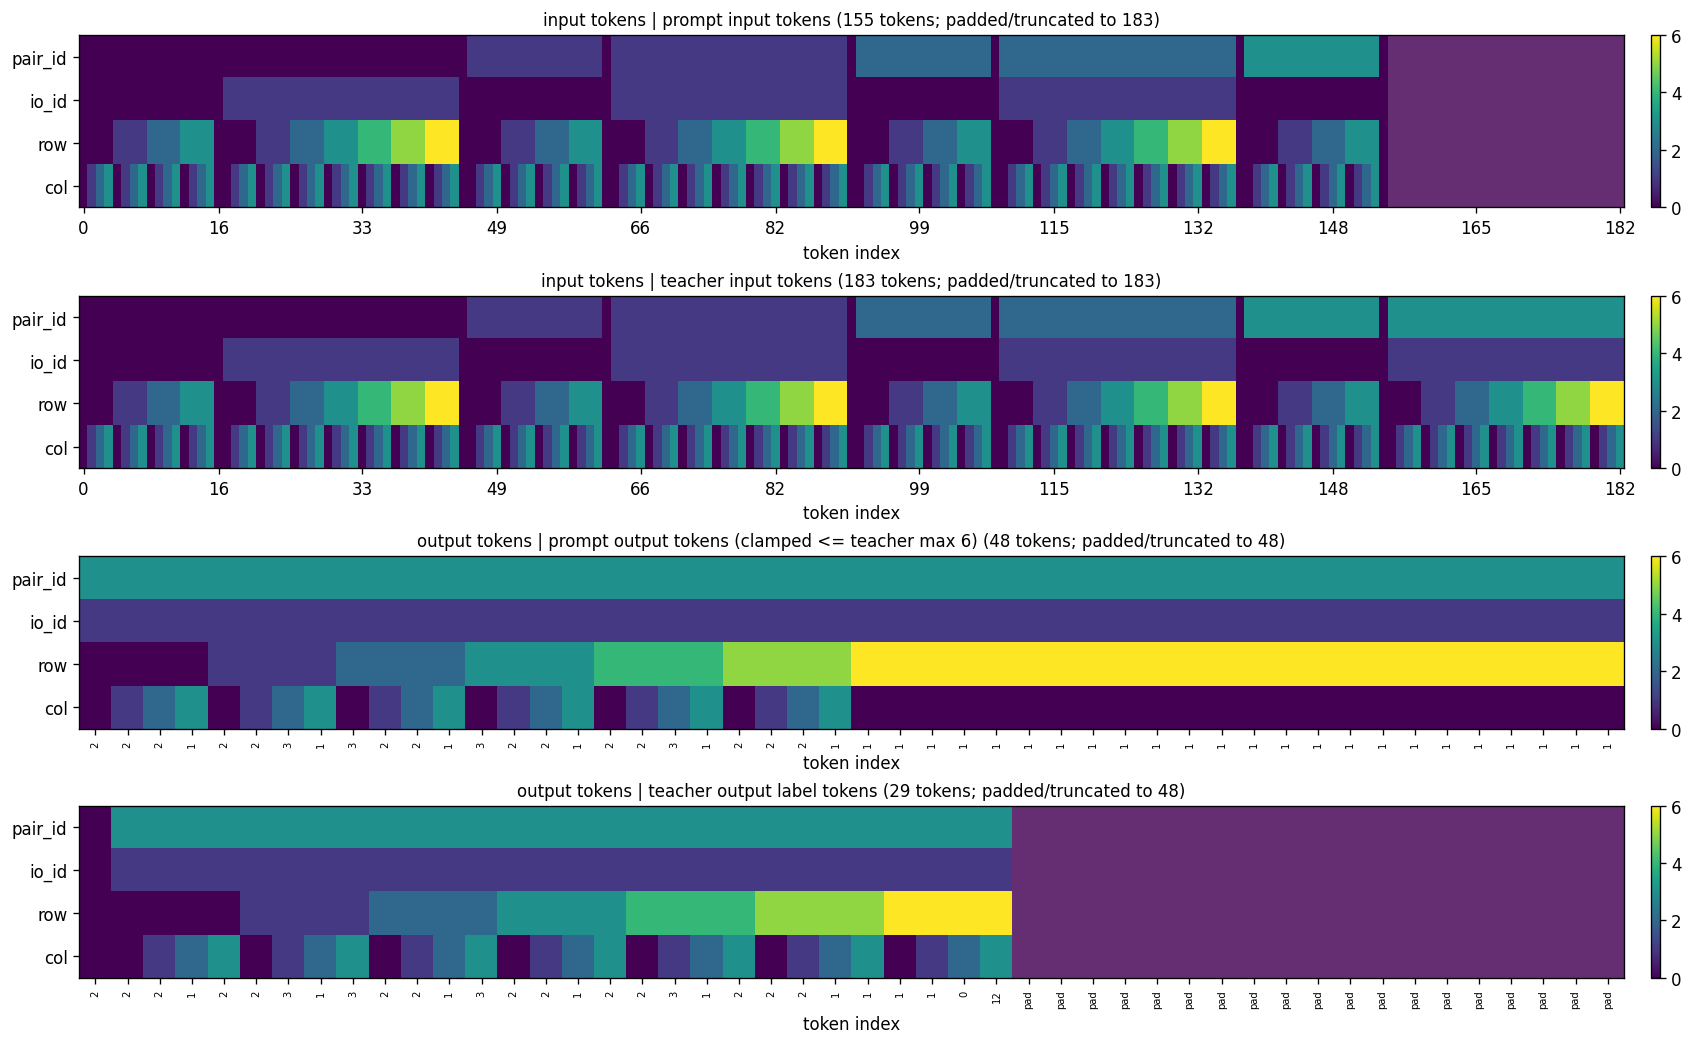

In [16]:
import pandas as pd

POSITION_ID_MAX_TOKENS = 220
POSITION_ID_PAD_VALUE = 0
POSITION_TOKEN_PAD_VALUE = 0
CLAMP_PROMPT_OUTPUT_POSITIONS_TO_TEACHER_OUTPUT_MAX = True
# CLAMP_PROMPT_OUTPUT_POSITIONS_TO_TEACHER_OUTPUT_MAX = False
POSITION_ID_COLUMNS = ["pair_id", "io_id", "row", "col"]


def _to_cpu(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu()
    if value is None:
        return None
    return torch.as_tensor(value)


def _cpu_batch(batch):
    return {key: (_to_cpu(value) if isinstance(value, torch.Tensor) else value) for key, value in batch.items()}


def _sample_slice(batch, sample_idx=0):
    seq_offsets = _to_cpu(batch.get("seq_offsets"))
    if seq_offsets is not None and int(seq_offsets.numel()) > sample_idx + 1:
        return slice(int(seq_offsets[sample_idx].item()), int(seq_offsets[sample_idx + 1].item()))

    seq_lengths = _to_cpu(batch.get("seq_lengths"))
    if seq_lengths is not None and int(seq_lengths.numel()) > sample_idx:
        start = int(seq_lengths[:sample_idx].sum().item())
        return slice(start, start + int(seq_lengths[sample_idx].item()))

    return slice(None)


def prompt_only_final_batch_with_positions(batch_cpu, target_tokens):
    batch = {key: value.cuda() for key, value in batch_cpu.items()}
    max_new_tokens = int(target_tokens.numel()) + int(PROMPT_ONLY_EXTRA_TOKENS)
    with torch.inference_mode():
        final_batch, preds, sample_metrics = _generate_urm_batch(
            base_model,
            batch,
            start_token_id=start_token_id,
            end_token_id=end_token_id,
            newline_token_id=ARC_TOKEN_EOS,
            max_new_tokens=max_new_tokens,
            cache_chunk_size=int(config.autoregressive_eval_cache_chunk_size),
        )[0]
    return _cpu_batch(final_batch), _cpu_batch(preds), sample_metrics


def _tokens_and_positions(batch, token_key="inputs", position_key="position_ids", sample_idx=0):
    sample = _sample_slice(batch, sample_idx)
    tokens = _to_cpu(batch[token_key])[sample].reshape(-1).to(torch.long)
    positions = _to_cpu(batch[position_key])[sample].reshape(int(tokens.numel()), -1).to(torch.long)
    return tokens, positions


def _answer_mask(batch, sample_idx=0):
    if batch.get("answer_mask") is None:
        tokens = _to_cpu(batch["inputs"])[_sample_slice(batch, sample_idx)].reshape(-1)
        return torch.zeros(tokens.shape, dtype=torch.bool)
    return _to_cpu(batch["answer_mask"])[_sample_slice(batch, sample_idx)].reshape(-1).to(torch.bool)


def _position_kind(positions):
    positions = np.asarray(positions)
    if positions.ndim != 2 or positions.shape[1] < 4:
        return np.array(["token"] * positions.shape[0], dtype=object)

    special = np.all(positions == 0, axis=1)
    kinds = np.full(positions.shape[0], "other", dtype=object)
    kinds[positions[:, 1] == 0] = "input-side"
    kinds[positions[:, 1] == 1] = "output-side"
    kinds[special] = "special"
    return kinds


def make_position_stream(name, role, tokens, positions):
    tokens = _to_cpu(tokens).reshape(-1).to(torch.long)
    positions = _to_cpu(positions).reshape(int(tokens.numel()), -1).to(torch.long)
    return {
        "name": name,
        "role": role,
        "tokens": tokens,
        "positions": positions,
    }


def make_position_dataframe(streams):
    rows = []
    for stream in streams:
        tokens = stream["tokens"].numpy()
        positions = stream["positions"].numpy()
        kinds = _position_kind(positions)
        for token_index, (token, position, kind) in enumerate(zip(tokens, positions, kinds)):
            row = {
                "source": stream["name"],
                "role": stream["role"],
                "token_index": token_index,
                "token": int(token),
                "kind": kind,
            }
            for dim, value in enumerate(position.tolist()):
                key = POSITION_ID_COLUMNS[dim] if dim < len(POSITION_ID_COLUMNS) else f"pos_{dim}"
                row[key] = int(value)
            rows.append(row)
    return pd.DataFrame(rows)


def _first_mismatch(left_values, right_values):
    common = min(len(left_values), len(right_values))
    if common:
        mismatch = np.flatnonzero(left_values[:common] != right_values[:common])
        if mismatch.size:
            return int(mismatch[0])
    return None if len(left_values) == len(right_values) else common


def compare_position_streams(left_name, left_stream, right_name, right_stream):
    left_tokens = left_stream["tokens"].numpy()
    right_tokens = right_stream["tokens"].numpy()
    left_positions = left_stream["positions"].numpy()
    right_positions = right_stream["positions"].numpy()
    common = min(len(left_tokens), len(right_tokens))

    if common:
        position_equal_each = np.all(left_positions[:common] == right_positions[:common], axis=1)
        token_equal_each = left_tokens[:common] == right_tokens[:common]
        first_position_mismatch = _first_mismatch(position_equal_each, np.ones(common, dtype=bool))
        first_token_mismatch = _first_mismatch(token_equal_each, np.ones(common, dtype=bool))
        position_match_rate = float(position_equal_each.mean())
        token_match_rate = float(token_equal_each.mean())
    else:
        first_position_mismatch = None if len(left_tokens) == len(right_tokens) else 0
        first_token_mismatch = first_position_mismatch
        position_match_rate = 0.0
        token_match_rate = 0.0

    if first_position_mismatch is None and len(left_tokens) != len(right_tokens):
        first_position_mismatch = common
    if first_token_mismatch is None and len(left_tokens) != len(right_tokens):
        first_token_mismatch = common

    return {
        "comparison": f"{left_name} vs {right_name}",
        "left_len": int(len(left_tokens)),
        "right_len": int(len(right_tokens)),
        "common_len": int(common),
        "position_match_rate": position_match_rate,
        "token_match_rate": token_match_rate,
        "first_position_mismatch": first_position_mismatch,
        "first_token_mismatch": first_token_mismatch,
    }


def shifted_teacher_output_position_stream(stream):
    shifted_positions = stream["positions"].clone()
    if int(shifted_positions.shape[0]) > 1:
        shifted_positions[:-1] = shifted_positions[1:].clone()
        shifted_positions[-1].zero_()
    return make_position_stream(stream["name"], f"{stream['role']} shifted", stream["tokens"], shifted_positions)


def clamp_stream_positions_for_plot(stream, max_value, note):
    clamped = dict(stream)
    clamped["positions"] = stream["positions"].clamp(max=int(max_value))
    clamped["role"] = f"{stream['role']} {note}"
    return clamped


def _padded_stream_for_plot(stream, target_len, max_tokens=POSITION_ID_MAX_TOKENS):
    plot_len = min(int(target_len), int(max_tokens))
    tokens = stream["tokens"][:plot_len].clone()
    positions = stream["positions"][:plot_len].clone()
    shown_len = int(tokens.numel())

    if shown_len < plot_len:
        token_pad = torch.full((plot_len - shown_len,), POSITION_TOKEN_PAD_VALUE, dtype=tokens.dtype)
        position_pad = torch.full(
            (plot_len - shown_len, int(stream["positions"].shape[-1])),
            POSITION_ID_PAD_VALUE,
            dtype=positions.dtype,
        )
        tokens = torch.cat([tokens, token_pad], dim=0)
        positions = torch.cat([positions, position_pad], dim=0)

    padded = dict(stream)
    padded["tokens"] = tokens
    padded["positions"] = positions
    padded["original_len"] = int(stream["tokens"].numel())
    padded["plot_len"] = plot_len
    padded["shown_len"] = shown_len
    return padded


def _padded_plot_streams(stream_groups, max_tokens=POSITION_ID_MAX_TOKENS):
    padded_streams = []
    for group_name, streams in stream_groups:
        target_len = max((int(stream["tokens"].numel()) for stream in streams), default=0)
        for stream in streams:
            padded = _padded_stream_for_plot(stream, target_len, max_tokens=max_tokens)
            padded["comparison_group"] = group_name
            padded_streams.append(padded)
    return padded_streams


def plot_position_id_streams(stream_groups, max_tokens=POSITION_ID_MAX_TOKENS):
    streams = _padded_plot_streams(stream_groups, max_tokens=max_tokens)
    fig, axes = plt.subplots(len(streams), 1, figsize=(14, 2.15 * len(streams)), constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, stream in zip(axes, streams):
        positions = stream["positions"].numpy()
        tokens = stream["tokens"].numpy()
        shown = int(stream["plot_len"])
        if shown == 0:
            ax.text(0.5, 0.5, "empty", ha="center", va="center")
            ax.set_axis_off()
            continue

        image = positions[:shown].T
        im = ax.imshow(image, aspect="auto", interpolation="nearest", cmap="viridis", vmin=POSITION_ID_PAD_VALUE)
        y_labels = POSITION_ID_COLUMNS[: image.shape[0]] if image.shape[0] <= len(POSITION_ID_COLUMNS) else [f"pos_{i}" for i in range(image.shape[0])]
        ax.set_yticks(np.arange(image.shape[0]))
        ax.set_yticklabels(y_labels)
        ax.set_title(
            f"{stream['comparison_group']} | {stream['name']} {stream['role']} "
            f"({stream['original_len']} tokens; padded/truncated to {shown})",
            fontsize=10,
        )
        ax.set_xlabel("token index")
        if shown <= 80:
            ax.set_xticks(np.arange(shown))
            ax.set_xticklabels(["pad" if idx >= stream["shown_len"] else str(int(token)) for idx, token in enumerate(tokens[:shown])], rotation=90, fontsize=6)
        else:
            tick_count = min(12, shown)
            ax.set_xticks(np.linspace(0, shown - 1, tick_count, dtype=int))
        if stream["shown_len"] < shown:
            ax.axvspan(stream["shown_len"] - 0.5, shown - 0.5, color="white", alpha=0.18, linewidth=0)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)

    plt.show()


prompt_final_batch, prompt_position_preds, prompt_position_metrics = prompt_only_final_batch_with_positions(prompt_batch, target_tokens)

prompt_input_tokens, prompt_input_positions = _tokens_and_positions(prompt_batch, position_key="prompt_position_ids")
prompt_output_mask = _answer_mask(prompt_final_batch)
prompt_final_tokens, prompt_final_positions = _tokens_and_positions(prompt_final_batch)
prompt_output_tokens = prompt_final_tokens[prompt_output_mask]
prompt_output_positions = prompt_final_positions[prompt_output_mask]

teacher_input_tokens, teacher_input_positions = _tokens_and_positions(teacher_batch)
teacher_output_mask = _answer_mask(teacher_batch)
teacher_labels = _to_cpu(teacher_batch["labels"])[_sample_slice(teacher_batch)].reshape(-1).to(torch.long)
if not bool(teacher_output_mask.any().item()):
    teacher_output_mask = teacher_labels != IGNORE_LABEL_ID
teacher_output_tokens = teacher_labels[teacher_output_mask]
teacher_output_positions = teacher_input_positions[teacher_output_mask]

prompt_input_stream = make_position_stream("prompt", "input tokens", prompt_input_tokens, prompt_input_positions)
prompt_output_stream = make_position_stream("prompt", "output tokens", prompt_output_tokens, prompt_output_positions)
teacher_input_stream = make_position_stream("teacher", "input tokens", teacher_input_tokens, teacher_input_positions)
teacher_output_stream = make_position_stream("teacher", "output label tokens", teacher_output_tokens, teacher_output_positions)
teacher_output_shifted_stream = shifted_teacher_output_position_stream(teacher_output_stream)
teacher_output_position_max = int(teacher_output_stream["positions"].max().item()) if int(teacher_output_stream["positions"].numel()) else POSITION_ID_PAD_VALUE
prompt_output_plot_stream = prompt_output_stream
if CLAMP_PROMPT_OUTPUT_POSITIONS_TO_TEACHER_OUTPUT_MAX:
    prompt_output_plot_stream = clamp_stream_positions_for_plot(
        prompt_output_stream,
        teacher_output_position_max,
        f"(clamped <= teacher max {teacher_output_position_max})",
    )

position_streams = [
    prompt_input_stream,
    teacher_input_stream,
    prompt_output_stream,
    teacher_output_stream,
]
position_stream_groups = [
    ("input tokens", [prompt_input_stream, teacher_input_stream]),
    ("output tokens", [prompt_output_plot_stream, teacher_output_stream]),
]
position_df = make_position_dataframe(position_streams)
position_summary = (
    position_df.groupby(["source", "role", "kind"], dropna=False)
    .agg(token_count=("token", "size"), first_index=("token_index", "min"), last_index=("token_index", "max"))
    .reset_index()
)
position_comparison = pd.DataFrame(
    [
        compare_position_streams("prompt input", prompt_input_stream, "teacher input", teacher_input_stream),
        compare_position_streams("prompt output", prompt_output_stream, "teacher output labels", teacher_output_stream),
        compare_position_streams("prompt output", prompt_output_stream, "teacher output labels shifted", teacher_output_shifted_stream),
    ]
)

print("position_id columns:", POSITION_ID_COLUMNS)
display(position_summary)
display(position_comparison)
display(position_df[position_df["role"] == "output tokens"])
display(position_df[position_df["role"] == "output label tokens"])
plot_position_id_streams(position_stream_groups)


In [12]:
# [3, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 1, 1, 1, 0, 
#  13, 3, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 3, 3, 2, 1, 1, 1, 1, 0, 12, 
#  3, 2, 3, 1, 3, 3, 2, 1, 3, 3, 3, 1, 1, 1, 1, 0, 
#  13, 3, 2, 3, 1, 3, 3, 2, 1, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 2, 1, 3, 2, 3, 1, 1, 1, 1, 0, 12, 
#  2, 2, 3, 1, 2, 3, 3, 1, 3, 2, 3, 1, 1, 1, 1, 0, 
#  13, 2, 2, 3, 1, 2, 3, 3, 1, 3, 2, 3, 1, 3, 2, 3, 1, 2, 3, 3, 1, 2, 2, 3, 1, 1, 1, 1, 0, 12, 
#  2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 1, 1, 1, 0, 
#  13, 2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0]

# [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 
#  -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 
#  -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 
#  3, 2, 3, 1, 3, 3, 2, 1, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 2, 1, 3, 2, 3, 1, 1, 1, 1, 0, 12, 
#  -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 
#  2, 2, 3, 1, 2, 3, 3, 1, 3, 2, 3, 1, 3, 2, 3, 1, 2, 3, 3, 1, 2, 2, 3, 1, 1, 1, 1, 0, 12, 
#  -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 
#  2, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 1, 3, 2, 2, 1, 2, 2, 3, 1, 2, 2, 2, 1, 1, 1, 1, 0, 12]


In [13]:
def choose_train_scan_examples(split_data, max_samples):
    rows = []
    num_groups = len(split_data["group_indices"]) - 1
    for group_id in range(num_groups):
        group_start = int(split_data["group_indices"][group_id])
        group_end = int(split_data["group_indices"][group_id + 1])
        for pi in range(group_start, group_end):
            start = int(split_data["puzzle_indices"][pi])
            end = int(split_data["puzzle_indices"][pi + 1])
            if end - start >= 2:
                rows.append((group_id, pi, start))
                break
        if len(rows) >= max_samples:
            break
    return rows


if RUN_TRAIN_SCAN:
    if SPLIT != "train":
        print("Skipping train scan because SPLIT is not 'train'.")
    else:
        scan_rows = []
        for sample_idx, (group_id, pi, ei) in enumerate(choose_train_scan_examples(split_data, TRAIN_SCAN_SAMPLE_COUNT)):
            item = compare_one(pi, ei, seed=RANDOM_SEED + sample_idx)
            scan_rows.append(
                {
                    "sample": sample_idx,
                    "group": group_id,
                    "puzzle_index": pi,
                    "example_index": ei,
                    "target_len": item["target_len"],
                    "teacher_acc": item["teacher_content_accuracy"],
                    "teacher_exact": item["teacher_content_exact"],
                    "teacher_end": item["teacher_end_correct"],
                    "prompt_acc": item["prompt_prefix_accuracy"],
                    "prompt_exact": item["prompt_exact"],
                    "prompt_len": item["prompt_generated_len"],
                    "prompt_ended": item["prompt_ended_before_limit"],
                    "prompt_mismatch": item["prompt_first_mismatch"],
                }
            )
        try:
            import pandas as pd
            scan_df = pd.DataFrame(scan_rows)
            display(scan_df)
            display(scan_df[["teacher_acc", "teacher_exact", "teacher_end", "prompt_acc", "prompt_exact", "prompt_ended"]].mean(numeric_only=True))
        except Exception:
            for row in scan_rows:
                print(row)

,sample,group,puzzle_index,example_index,target_len,teacher_acc,teacher_exact,teacher_end,prompt_acc,prompt_exact,prompt_len,prompt_ended,prompt_mismatch
0,0,0,0,0,28,1.000000,True,True,0.964286,False,48,False,"{'index': 27, 'target': 0, 'generated': 1}"
1,1,1,72,19152,196,0.994898,False,True,0.954082,False,216,False,"{'index': 3, 'target': 2, 'generated': 8}"
2,2,2,1072,285152,100,0.990000,False,True,0.750000,False,120,False,"{'index': 0, 'target': 2, 'generated': 10}"
3,3,3,2072,552152,50,1.000000,True,True,0.980000,False,70,False,"{'index': 49, 'target': 0, 'generated': 1}"


teacher_acc      0.996224
teacher_exact    0.500000
teacher_end      1.000000
prompt_acc       0.912092
prompt_exact     0.000000
prompt_ended     0.000000
dtype: float64

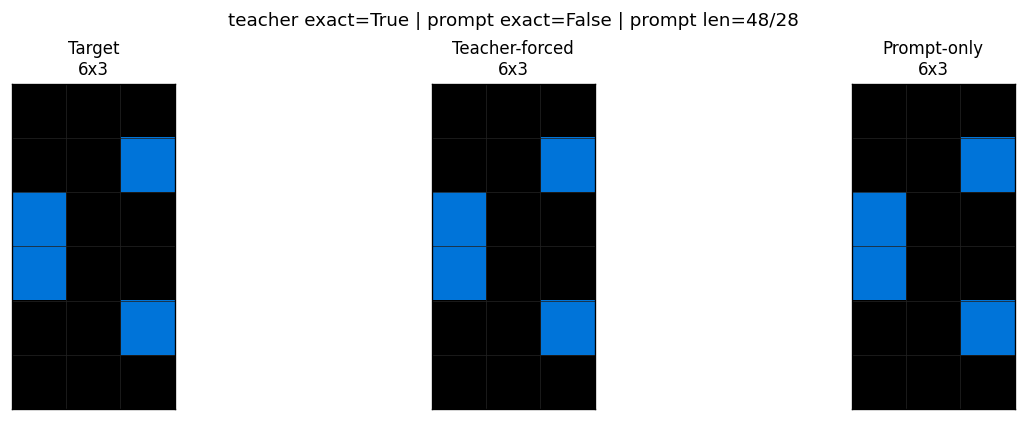

In [14]:
shape = target_solution_shape(split_data, example_index)
target_grid = tokens_to_grid(comparison["target_tokens"], shape)
teacher_grid = tokens_to_grid(comparison["teacher_tokens"][: comparison["target_len"]], shape)
prompt_padded = torch.full_like(comparison["target_tokens"], ARC_TOKEN_PAD)
copy_len = min(int(prompt_padded.numel()), int(comparison["prompt_tokens"].numel()))
if copy_len:
    prompt_padded[:copy_len] = comparison["prompt_tokens"][:copy_len]
prompt_grid = tokens_to_grid(prompt_padded, shape)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), constrained_layout=True)
render_grid(axes[0], target_grid, "Target")
render_grid(axes[1], teacher_grid, "Teacher-forced", wrong_mask=(teacher_grid != target_grid))
render_grid(axes[2], prompt_grid, "Prompt-only", wrong_mask=(prompt_grid != target_grid))
fig.suptitle(
    f"teacher exact={comparison['teacher_content_exact']} | prompt exact={comparison['prompt_exact']} | "
    f"prompt len={comparison['prompt_generated_len']}/{comparison['target_len']}",
    fontsize=11,
)
plt.show()